**生成式 AI 的使用**：在本课程作业中，使用生成式 AI 须遵守与协作相关的相同政策。与其他协作者一样，每位学生都必须独立于交互输出自行写出解答，并且提交内容中应注明协作的性质。使用生成式 AI 工具完成作业的大部分章节不符合本课程作业的初衷，并将违反[荣誉准则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = "cs231n/assignments/assignment2/"
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the COCO dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_coco_dataset.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# 使用 RNN 进行图像描述
在本练习中，你将实现普通循环神经网络（Recurrent Neural Network, RNN），并用它们训练一个能够为图像生成新描述的模型。


In [23]:

# Setup cell.
import time, os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.rnn_layers_pytorch import *
from cs231n.captioning_solver_pytorch import CaptioningSolverPytorch
from cs231n.classifiers.rnn_pytorch import CaptioningRNN
from cs231n.coco_utils import load_coco_data, sample_coco_minibatch, decode_captions
from cs231n.image_utils import image_from_url

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # Set default size of plots.
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# COCO 数据集
在本练习中，我们将使用 2014 版的 [COCO 数据集](https://cocodataset.org/)，它是图像描述任务的标准测试平台。该数据集包含 80,000 张训练图像和 40,000 张验证图像，每张图像都配有 5 条由 Amazon Mechanical Turk 工作人员撰写的描述。

**图像特征。** 我们已经预处理了数据并为你提取好特征。对于所有图像，我们从在 ImageNet 上预训练的 VGG-16 网络的 fc7 层提取了特征，并将其存储在文件 `train2014_vgg16_fc7.h5` 和 `val2014_vgg16_fc7.h5` 中。为了减少处理时间和内存需求，我们使用主成分分析（Principal Component Analysis, PCA）将特征维度从 4096 降至 512，并将这些特征存储在文件 `train2014_vgg16_fc7_pca.h5` 和 `val2014_vgg16_fc7_pca.h5` 中。原始图像占用近 20GB 空间，因此下载内容中未包含它们。由于所有图像都来自 Flickr，我们把训练图像和验证图像的 URL 分别存储在文件 `train2014_urls.txt` 和 `val2014_urls.txt` 中。这样，你就可以在可视化时按需下载图像。

**描述。** 直接处理字符串效率较低，因此我们将使用描述的编码版本。每个单词都被分配一个整数 ID，从而可以用整数序列表示一条描述。整数 ID 与单词之间的映射位于文件 `coco2014_vocab.json` 中；你可以使用文件 `cs231n/coco_utils.py` 中的函数 `decode_captions`，将由整数 ID 构成的 NumPy 数组转换回字符串。

**标记。** 我们会向词表中加入几个特殊标记，并且已经为你处理好了与这些特殊标记有关的所有实现细节。我们分别在每条描述的开头添加特殊的 `<START>` 标记，在结尾添加 `<END>` 标记。低频词会被替换为特殊的 `<UNK>` 标记（表示“未知”）。此外，由于我们希望用包含不同长度描述的小批量进行训练，因此会在 `<END>` 标记之后使用特殊的 `<NULL>` 标记填充较短的描述，并且不为 `<NULL>` 标记计算损失或梯度。

你可以使用文件 `cs231n/coco_utils.py` 中的 `load_coco_data` 函数加载所有 COCO 数据（描述、特征、URL 和词表）。运行以下单元来完成加载：

In [24]:
# Load COCO data from disk into a dictionary.
# We'll work with dimensionality-reduced features for the remainder of this assignment,
# but you can also experiment with the original features on your own by changing the flag below.
data = load_coco_data(pca_features=True)

# Print out all the keys and values from the data dictionary.
for k, v in data.items():
    if type(v) == np.ndarray:
        print(k, type(v), v.shape, v.dtype)
    else:
        print(k, type(v), len(v))

base dir  C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment2\cs231n\datasets/coco_captioning
train_captions <class 'numpy.ndarray'> (400135, 17) int32
train_image_idxs <class 'numpy.ndarray'> (400135,) int32
val_captions <class 'numpy.ndarray'> (195954, 17) int32
val_image_idxs <class 'numpy.ndarray'> (195954,) int32
train_features <class 'numpy.ndarray'> (82783, 512) float32
val_features <class 'numpy.ndarray'> (40504, 512) float32
idx_to_word <class 'list'> 1004
word_to_idx <class 'dict'> 1004
train_urls <class 'numpy.ndarray'> (82783,) <U63
val_urls <class 'numpy.ndarray'> (40504,) <U63


## 检查数据
在开始处理数据集之前，先查看其中的一些样例始终是个好主意。

你可以使用文件 `cs231n/coco_utils.py` 中的 `sample_coco_minibatch` 函数，从 `load_coco_data` 返回的数据结构中采样数据小批量。运行以下内容可采样一个较小的训练数据批次，并展示图像及其描述。多运行几次并查看结果，有助于你形成对数据集的直观认识。


In [ ]:
# Sample a minibatch and show the images and captions.
# If you get an error, the URL just no longer exists, so don't worry!
# You can re-sample as many times as you want.
batch_size = 3

captions, features, urls = sample_coco_minibatch(data, batch_size=batch_size)
for i, (caption, url) in enumerate(zip(captions, urls)):
    plt.imshow(image_from_url(url))
    plt.axis('off')
    caption_str = decode_captions(caption, data['idx_to_word'])
    plt.title(caption_str)
    plt.show()

# 循环神经网络
正如课堂中讨论的那样，我们将使用循环神经网络（RNN）语言模型完成图像描述任务。文件 `cs231n/rnn_layers_pytorch.py` 包含循环神经网络所需的不同层类型的实现，文件 `cs231n/classifiers/rnn_pytorch.py` 则使用这些层实现图像描述模型。

我们首先将在 `cs231n/rnn_layers_pytorch.py` 中实现不同类型的 RNN 层。

_深入理解 RNN 的可选阅读材料：https://www.deeplearningbook.org/contents/rnn.html#pf7_


# 普通 RNN：单步前向传播
打开文件 `cs231n/rnn_layers_pytorch.py`。该文件实现了循环神经网络中常用的不同层类型的前向传播。请注意，由于我们使用 PyTorch，反向传播将由 PyTorch 的 autograd 自动微分机制处理。

首先实现函数 `rnn_step_forward`，它负责普通循环神经网络在单个时间步上的前向传播。完成后运行以下内容检查你的实现。你应该看到 `e-8` 量级或更小的误差。


In [ ]:
N, D, H = 3, 10, 4

x = torch.from_numpy(np.linspace(-0.4, 0.7, num=N*D).reshape(N, D))
prev_h = torch.from_numpy(np.linspace(-0.2, 0.5, num=N*H).reshape(N, H))
Wx = torch.from_numpy(np.linspace(-0.1, 0.9, num=D*H).reshape(D, H))
Wh = torch.from_numpy(np.linspace(-0.3, 0.7, num=H*H).reshape(H, H))
b = torch.from_numpy(np.linspace(-0.2, 0.4, num=H))

next_h = rnn_step_forward(x, prev_h, Wx, Wh, b).numpy()
expected_next_h = np.asarray([
  [-0.58172089, -0.50182032, -0.41232771, -0.31410098],
  [ 0.66854692,  0.79562378,  0.87755553,  0.92795967],
  [ 0.97934501,  0.99144213,  0.99646691,  0.99854353]])

print('next_h error: ', rel_error(expected_next_h, next_h))

# 普通 RNN：单步反向传播
由于我们使用 PyTorch 实现了 `rnn_step_forward`，因此**不需要**实现 `rnn_step_backward`。我们可以使用数值梯度检查器验证 PyTorch autograd 的反向传播。

不过，如果你想挑战一下，也可以尝试自行实现 `rnn_step_backward`，但本作业不要求这样做。


In [ ]:
from cs231n.rnn_layers_pytorch import rnn_step_forward

# Create test inputs
np.random.seed(231)
N, D, H = 4, 5, 6
x = torch.from_numpy(np.random.randn(N, D))
h = torch.from_numpy(np.random.randn(N, H))
Wx = torch.from_numpy(np.random.randn(D, H))
Wh = torch.from_numpy(np.random.randn(H, H))
b = torch.from_numpy(np.random.randn(H))

# Enable gradient tracking and do rnn forward pass
for tensor in [x, h, Wx, Wh, b]:
  tensor.requires_grad_()
next_h = rnn_step_forward(x, h, Wx, Wh, b)

# Simulate random upstream gradients and do a backward pass using pytorch's
# autograd.
dnext_h = torch.from_numpy(np.random.randn(*next_h.shape))
next_h.backward(dnext_h)

# Collect gradient in separate numpy arrays
dx = x.grad.detach().numpy()
dh = h.grad.detach().numpy()
dWx = Wx.grad.detach().numpy()
dWh = Wh.grad.detach().numpy()
db = b.grad.detach().numpy()
dnext_h = dnext_h.detach().numpy()

# Also convert test inputs to numpy arrays
x =  x.detach().numpy()
h =  h.detach().numpy()
Wx = Wx.detach().numpy()
Wh = Wh.detach().numpy()
b =  b.detach().numpy()

# Wrap our forward pass to support numpy array input and output. We use
# `torch.no_grad()` to explicitly disable gradient tracking.
def rnn_step_forward_numpy(x, h, Wx, Wh, b):
  with torch.no_grad():
    return rnn_step_forward(
        torch.from_numpy(x),
        torch.from_numpy(h),
        torch.from_numpy(Wx),
        torch.from_numpy(Wh),
        torch.from_numpy(b),
    ).numpy()

# Compute numerical gradients and compare.
fx = lambda x: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fh = lambda h: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fWx = lambda Wx: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fWh = lambda Wh: rnn_step_forward_numpy(x, h, Wx, Wh, b)
fb = lambda b: rnn_step_forward_numpy(x, h, Wx, Wh, b)

dx_num = eval_numerical_gradient_array(fx, x, dnext_h)
dh_num = eval_numerical_gradient_array(fh, h, dnext_h)
dWx_num = eval_numerical_gradient_array(fWx, Wx, dnext_h)
dWh_num = eval_numerical_gradient_array(fWh, Wh, dnext_h)
db_num = eval_numerical_gradient_array(fb, b, dnext_h)

# You should see errors on the order of 1e-9 or less
print('dx error: ', rel_error(dx_num, dx))
print('dh error: ', rel_error(dh_num, dh))
print('dWx error: ', rel_error(dWx_num, dWx))
print('dWh error: ', rel_error(dWh_num, dWh))
print('db error: ', rel_error(db_num, db))

# 普通 RNN：前向传播
现在你已经实现了普通 RNN 单个时间步的前向传播，接下来要用它实现一个能够处理完整数据序列的 RNN。

在文件 `cs231n/rnn_layers_pytorch.py` 中实现函数 `rnn_forward`。你应使用上面定义的 `rnn_step_forward` 函数来实现它。完成后运行以下内容检查你的实现。你应该看到 `e-7` 量级或更小的误差。


In [ ]:
from cs231n.rnn_layers_pytorch import rnn_forward

N, T, D, H = 2, 3, 4, 5

x = torch.from_numpy(np.linspace(-0.1, 0.3, num=N*T*D).reshape(N, T, D))
h0 = torch.from_numpy(np.linspace(-0.3, 0.1, num=N*H).reshape(N, H))
Wx = torch.from_numpy(np.linspace(-0.2, 0.4, num=D*H).reshape(D, H))
Wh = torch.from_numpy(np.linspace(-0.4, 0.1, num=H*H).reshape(H, H))
b = torch.from_numpy(np.linspace(-0.7, 0.1, num=H))

h = rnn_forward(x, h0, Wx, Wh, b).numpy()
expected_h = np.asarray([
  [
    [-0.42070749, -0.27279261, -0.11074945,  0.05740409,  0.22236251],
    [-0.39525808, -0.22554661, -0.0409454,   0.14649412,  0.32397316],
    [-0.42305111, -0.24223728, -0.04287027,  0.15997045,  0.35014525],
  ],
  [
    [-0.55857474, -0.39065825, -0.19198182,  0.02378408,  0.23735671],
    [-0.27150199, -0.07088804,  0.13562939,  0.33099728,  0.50158768],
    [-0.51014825, -0.30524429, -0.06755202,  0.17806392,  0.40333043]]])
print('h error: ', rel_error(expected_h, h))

# 普通 RNN：反向传播
与前面一样，我们可以使用数值梯度检查器验证 PyTorch autograd 的反向传播。如果你愿意，也可以尝试自行实现 `rnn_step_backward`，但本作业不要求这样做。



In [ ]:
from cs231n.rnn_layers_pytorch import rnn_forward

# Create test inputs
np.random.seed(231)
N, D, T, H = 2, 3, 10, 5
x = torch.from_numpy(np.random.randn(N, T, D))
h0 = torch.from_numpy(np.random.randn(N, H))
Wx = torch.from_numpy(np.random.randn(D, H))
Wh = torch.from_numpy(np.random.randn(H, H))
b = torch.from_numpy(np.random.randn(H))

# Enable gradient tracking and do forward pass
for tensor in [x, h0, Wx, Wh, b]:
  tensor.requires_grad_()
h = rnn_forward(x, h0, Wx, Wh, b)

# Simulate random upstream gradients and do a backward pass using pytorch's
# autograd.
dh = torch.from_numpy(np.random.randn(*h.shape))
h.backward(dh)

# Collect gradient in separate numpy arrays
dx = x.grad.detach().numpy()
dh0 = h0.grad.detach().numpy()
dWx = Wx.grad.detach().numpy()
dWh = Wh.grad.detach().numpy()
db = b.grad.detach().numpy()
dh = dh.detach().numpy()

# Also convert test inputs to numpy arrays
x =  x.detach().numpy()
h0 =  h0.detach().numpy()
Wx = Wx.detach().numpy()
Wh = Wh.detach().numpy()
b =  b.detach().numpy()

# Wrap our forward pass to support numpy array input and output. We use
# `torch.no_grad()` to explicitly disable gradient tracking.
def rnn_forward_numpy(x, h0, Wx, Wh, b):
  with torch.no_grad():
    return rnn_forward(
        torch.from_numpy(x),
        torch.from_numpy(h0),
        torch.from_numpy(Wx),
        torch.from_numpy(Wh),
        torch.from_numpy(b),
    ).numpy()


fx = lambda x: rnn_forward_numpy(x, h0, Wx, Wh, b)
fh0 = lambda h0: rnn_forward_numpy(x, h0, Wx, Wh, b)
fWx = lambda Wx: rnn_forward_numpy(x, h0, Wx, Wh, b)
fWh = lambda Wh: rnn_forward_numpy(x, h0, Wx, Wh, b)
fb = lambda b: rnn_forward_numpy(x, h0, Wx, Wh, b)

dx_num = eval_numerical_gradient_array(fx, x, dh)
dh0_num = eval_numerical_gradient_array(fh0, h0, dh)
dWx_num = eval_numerical_gradient_array(fWx, Wx, dh)
dWh_num = eval_numerical_gradient_array(fWh, Wh, dh)
db_num = eval_numerical_gradient_array(fb, b, dh)

# You should see errors on the order of 1e-6 or less
print('dx error: ', rel_error(dx_num, dx))
print('dh0 error: ', rel_error(dh0_num, dh0))
print('dWx error: ', rel_error(dWx_num, dWx))
print('dWh error: ', rel_error(dWh_num, dWh))
print('db error: ', rel_error(db_num, db))

# 词嵌入：前向传播
在深度学习系统中，我们通常使用向量表示单词。词表中的每个单词都将对应一个向量，这些向量会与系统的其余部分共同学习。

在文件 `cs231n/rnn_layers_pytorch.py` 中实现函数 `word_embedding_forward`，将单词（以整数表示）转换为向量。运行以下内容检查你的实现。你应该看到 `e-8` 量级或更小的误差。


In [ ]:
N, T, V, D = 2, 4, 5, 3

x = torch.from_numpy(np.asarray([[0, 3, 1, 2], [2, 1, 0, 3]]))
W = torch.from_numpy(np.linspace(0, 1, num=V*D).reshape(V, D))

out = word_embedding_forward(x, W).numpy()
expected_out = np.asarray([
 [[ 0.,          0.07142857,  0.14285714],
  [ 0.64285714,  0.71428571,  0.78571429],
  [ 0.21428571,  0.28571429,  0.35714286],
  [ 0.42857143,  0.5,         0.57142857]],
 [[ 0.42857143,  0.5,         0.57142857],
  [ 0.21428571,  0.28571429,  0.35714286],
  [ 0.,          0.07142857,  0.14285714],
  [ 0.64285714,  0.71428571,  0.78571429]]])

print('out error: ', rel_error(expected_out, out))

# 词嵌入：反向传播
与前面一样，我们可以使用数值梯度检查器验证 PyTorch autograd 的反向传播。如果你愿意，也可以尝试自行实现 `word_embedding_backward`，但本作业不要求这样做。


In [ ]:
np.random.seed(231)

N, T, V, D = 50, 3, 5, 6
x = torch.from_numpy(np.random.randint(V, size=(N, T)))
W = torch.from_numpy(np.random.randn(V, D))
W.requires_grad_()

out = word_embedding_forward(x, W)
dout = torch.from_numpy(np.random.randn(*out.shape))
out.backward(dout)

dW = W.grad.detach().numpy()
x = x.detach().numpy()
W = W.detach().numpy()
dout = dout.detach().numpy()

def word_embedding_forward_numpy(x, W):
  return word_embedding_forward(
      torch.from_numpy(x),
      torch.from_numpy(W),
  ).numpy()

f = lambda W: word_embedding_forward_numpy(x, W)
dW_num = eval_numerical_gradient_array(f, W, dout)

# You should see an error on the order of 1e-11 or less
print('dW error: ', rel_error(dW, dW_num))

# 时间仿射层
在每个时间步，我们使用一个仿射函数，将该时间步的 RNN 隐藏向量转换为词表中各单词的分数。由于这与作业 1 中实现的仿射层非常相似，我们已经在 `temporal_affine_forward` 中为你提供了这个函数。运行以下内容对该实现进行数值梯度检查。你应该看到 `e-9` 量级或更小的误差。


In [ ]:
np.random.seed(231)

# Gradient check for temporal affine layer
N, T, D, M = 2, 3, 4, 5
x = torch.from_numpy(np.random.randn(N, T, D))
w = torch.from_numpy(np.random.randn(D, M))
b = torch.from_numpy(np.random.randn(M))

for tensor in [x, w, b]:
  tensor.requires_grad_()
out = temporal_affine_forward(x, w, b)
dout = torch.from_numpy(np.random.randn(*out.shape))
out.backward(dout)

dx = x.grad.detach().numpy()
dw = w.grad.detach().numpy()
db = b.grad.detach().numpy()

x = x.detach().numpy()
w = w.detach().numpy()
b = b.detach().numpy()
dout = dout.detach().numpy()

def temporal_affine_forward_numpy(x, w, b):
  return temporal_affine_forward(
      torch.from_numpy(x),
      torch.from_numpy(w),
      torch.from_numpy(b),
  ).numpy()

fx = lambda x: temporal_affine_forward_numpy(x, w, b)
fw = lambda w: temporal_affine_forward_numpy(x, w, b)
fb = lambda b: temporal_affine_forward_numpy(x, w, b)

dx_num = eval_numerical_gradient_array(fx, x, dout)
dw_num = eval_numerical_gradient_array(fw, w, dout)
db_num = eval_numerical_gradient_array(fb, b, dout)

print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

# 时间 Softmax 损失
在 RNN 语言模型中，每个时间步都会为词表中的每个单词产生一个分数。我们知道每个时间步的真实单词，因此使用 softmax 损失函数计算各时间步的损失和梯度。我们将损失沿时间求和，再对小批量取平均。

不过这里有一个小问题：由于我们以小批量形式处理数据，而不同描述的长度可能不同，因此会在每条描述末尾追加 `<NULL>` 标记，使它们具有相同长度。我们不希望这些 `<NULL>` 标记计入损失或梯度，因此除了分数和真实标签之外，损失函数还接收一个 `mask` 数组，用来指明分数中的哪些元素应计入损失。

由于这与作业 1 中实现的 softmax 损失函数非常相似，我们已经为你实现了该损失函数；请查看文件 `cs231n/rnn_layers_pytorch.py` 中的 `temporal_softmax_loss` 函数。

运行以下单元，对损失进行合理性检查，并对函数执行数值梯度检查。你应该看到 dx 的误差处于 `e-7` 量级或更小。


In [ ]:
# Sanity check for temporal softmax loss
from cs231n.rnn_layers_pytorch import temporal_softmax_loss

N, T, V = 100, 1, 10

def check_loss(N, T, V, p):
    x = 0.001 * torch.from_numpy(np.random.randn(N, T, V))
    y = torch.from_numpy(np.random.randint(V, size=(N, T)))
    mask = torch.from_numpy(np.random.rand(N, T)) <= p
    print(temporal_softmax_loss(x, y, mask).item())

check_loss(100, 1, 10, 1.0)   # Should be about 2.3
check_loss(100, 10, 10, 1.0)  # Should be about 23
check_loss(5000, 10, 10, 0.1) # Should be within 2.2-2.4

# Gradient check for temporal softmax loss
np.random.seed(231231)
N, T, V = 7, 8, 9

x = torch.from_numpy(np.random.randn(N, T, V))
y = torch.from_numpy(np.random.randint(V, size=(N, T)))
mask = torch.from_numpy(np.random.rand(N, T) > 0.5)

x.requires_grad_()
loss = temporal_softmax_loss(x, y, mask, verbose=False)
loss.backward()
dx = x.grad.detach().numpy()
x = x.detach().numpy()
dx_num = eval_numerical_gradient(
    lambda x: temporal_softmax_loss(torch.from_numpy(x), y, mask), x, verbose=False)

print('dx error: ', rel_error(dx, dx_num))

# 用于图像描述的 RNN
现在你已经实现了所有必要的层，可以将它们组合起来构建图像描述模型。打开文件 `cs231n/classifiers/rnn_pytorch.py`，查看 `CaptioningRNN` 类。

在 `loss` 函数中实现模型的前向传播。目前只需实现普通 RNN 对应的 `cell_type='rnn'` 情况；稍后你将实现 LSTM 的情况。完成后运行以下内容，使用一个小型测试用例检查前向传播；你应该看到 `e-10` 量级或更小的误差。


In [27]:
N, D, W, H = 10, 20, 30, 40
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(word_to_idx)
T = 13

model = CaptioningRNN(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    hidden_dim=H,
    cell_type='rnn',
    dtype=torch.float64
)

# Set all model parameters to fixed values
for k, v in model.params.items():
    model.params[k] = torch.from_numpy(
        np.linspace(-1.4, 1.3, num=v.numel()).reshape(*v.shape))

features = torch.from_numpy(np.linspace(-1.5, 0.3, num=(N * D)).reshape(N, D))
captions = torch.from_numpy((np.arange(N * T) % V).reshape(N, T))

loss = model.loss(features, captions).item()
expected_loss = 9.83235591003

print('loss: ', loss)
print('expected loss: ', expected_loss)
print('difference: ', abs(loss - expected_loss))

loss:  9.83235591002739
expected loss:  9.83235591003
difference:  2.609468197078968e-12


运行以下单元，对 `CaptioningRNN` 类执行数值梯度检查；你应该看到 `e-6` 量级左右或更小的误差。


In [28]:
np.random.seed(231)
torch.manual_seed(231)

batch_size = 2
timesteps = 3
input_dim = 4
wordvec_dim = 5
hidden_dim = 6
word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
vocab_size = len(word_to_idx)

captions = torch.from_numpy(np.random.randint(vocab_size, size=(batch_size, timesteps)))
features = torch.from_numpy(np.random.randn(batch_size, input_dim))

model = CaptioningRNN(
    word_to_idx,
    input_dim=input_dim,
    wordvec_dim=wordvec_dim,
    hidden_dim=hidden_dim,
    cell_type='rnn',
    dtype=torch.float64,
)

for k, v in model.params.items():
  v.requires_grad_()
loss = model.loss(features, captions)
loss.backward()
grads = {k: v.grad.detach().numpy() for k, v in model.params.items()}
for k, v in model.params.items():
  v.requires_grad_(False)

for param_name in sorted(grads.keys()):
    def fn(val):
      model.params[param_name] = torch.from_numpy(val)
      ret = model.loss(features, captions).numpy()
      return ret

    param_grad_num = eval_numerical_gradient(
        fn, model.params[param_name].numpy(), verbose=False, h=1e-6)

    e = rel_error(param_grad_num, grads[param_name])
    print('%s relative error: %e' % (param_name, e))

W_embed relative error: 7.405825e-09
W_proj relative error: 1.627846e-08
W_vocab relative error: 5.813051e-09
Wh relative error: 3.722645e-09
Wx relative error: 3.272434e-06
b relative error: 2.259961e-10
b_proj relative error: 7.720396e-10
b_vocab relative error: 4.089136e-09


# 在小数据集上过拟合 RNN 图像描述模型
与上一份作业中用于训练图像分类模型的 `Solver` 类类似，本作业使用 `CaptioningSolverPytorch` 类训练图像描述模型。打开文件 `cs231n/captioning_solver_pytorch.py`，通读 `CaptioningSolverPytorch` 类；它看起来应该非常熟悉。

熟悉该 API 后，运行以下内容，确保你的模型能够过拟合由 100 个训练样例组成的小样本。最终损失应低于 0.1。


base dir  C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment2\cs231n\datasets/coco_captioning
(Iteration 1 / 100) loss: 80.072144
(Iteration 11 / 100) loss: 14.927378
(Iteration 21 / 100) loss: 1.086582
(Iteration 31 / 100) loss: 0.256384
(Iteration 41 / 100) loss: 0.057835
(Iteration 51 / 100) loss: 0.018930
(Iteration 61 / 100) loss: 0.009394
(Iteration 71 / 100) loss: 0.006798
(Iteration 81 / 100) loss: 0.005706
(Iteration 91 / 100) loss: 0.004793


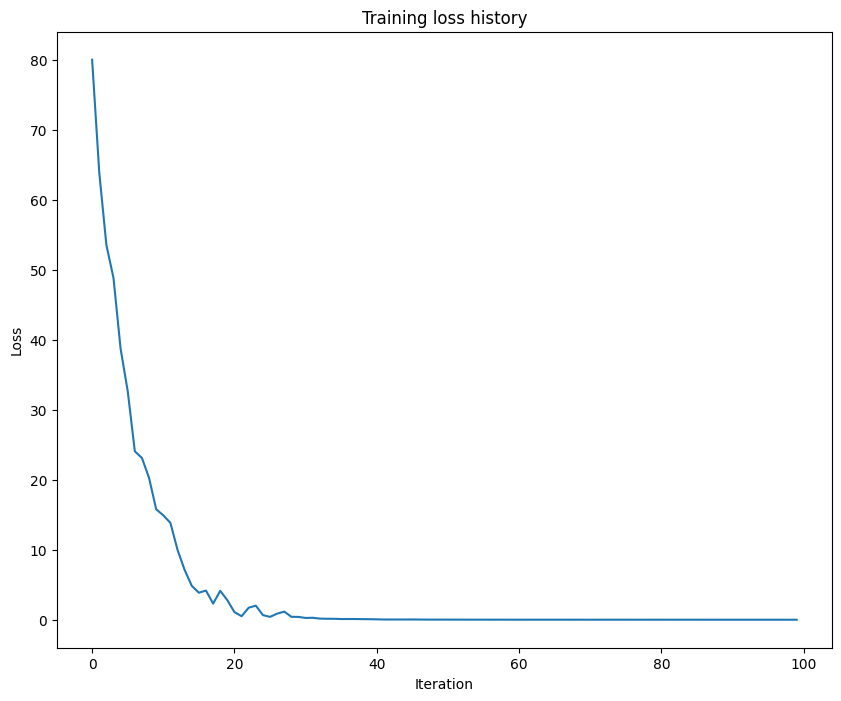

In [31]:
np.random.seed(231)
torch.manual_seed(231)

small_data = load_coco_data(max_train=50)

small_rnn_model = CaptioningRNN(
    cell_type='rnn',
    word_to_idx=data['word_to_idx'],
    input_dim=data['train_features'].shape[1],
    hidden_dim=1024,
    wordvec_dim=256,
)

small_rnn_solver = CaptioningSolverPytorch(
    small_rnn_model, small_data,
    num_epochs=50,
    batch_size=25,
    learning_rate=5e-3,
    verbose=True, print_every=10,
)

small_rnn_solver.train()

# Plot the training losses.
plt.plot(small_rnn_solver.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training loss history')
plt.show()

打印最终训练损失。最终损失应低于 0.1。


In [32]:
print('Final loss: ', small_rnn_solver.loss_history[-1])

Final loss:  0.00368393


# 测试时的 RNN 采样
与分类模型不同，图像描述模型在训练时和测试时的行为差异很大。在训练时，我们可以访问真实描述，因此在每个时间步都将真实单词作为 RNN 的输入。在测试时，我们从每个时间步的词表概率分布中采样，并将采样结果作为下一个时间步 RNN 的输入。

在文件 `cs231n/classifiers/rnn_pytorch.py` 中实现用于测试时采样的 `sample` 方法。完成后运行以下内容，分别使用过拟合模型从训练数据和验证数据中采样。训练数据上的样本应该非常好；但验证数据上的样本可能没有意义。


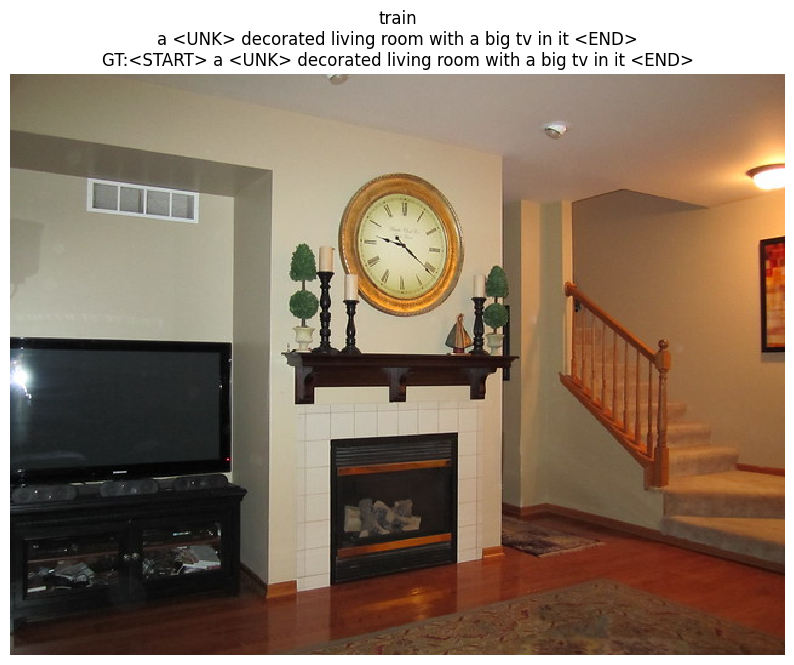

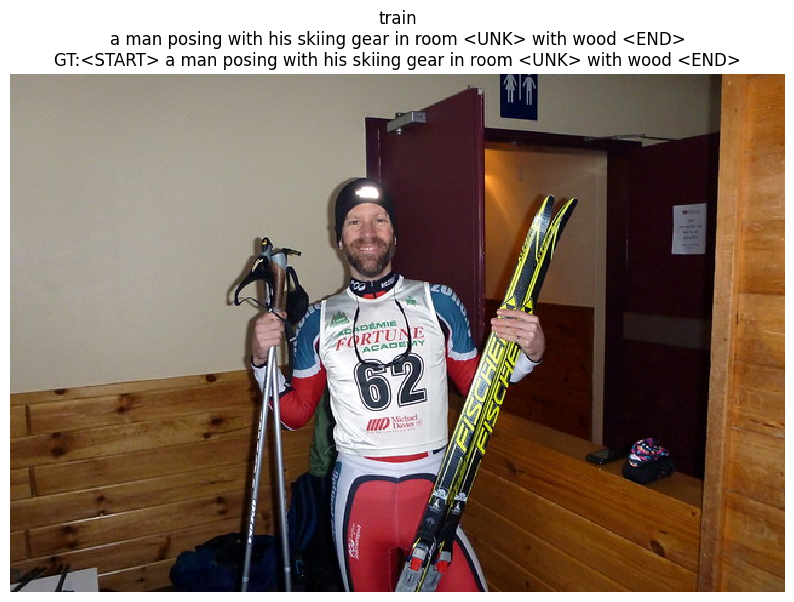

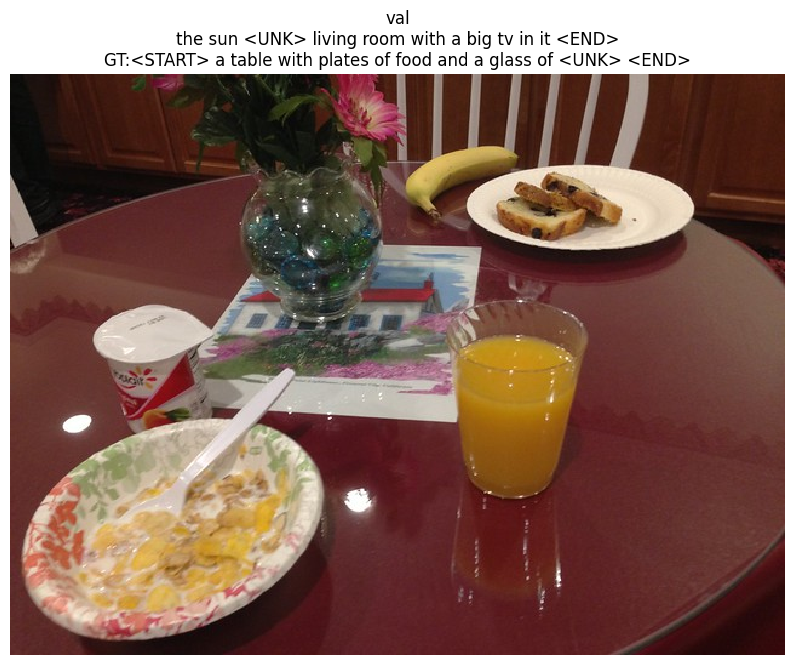

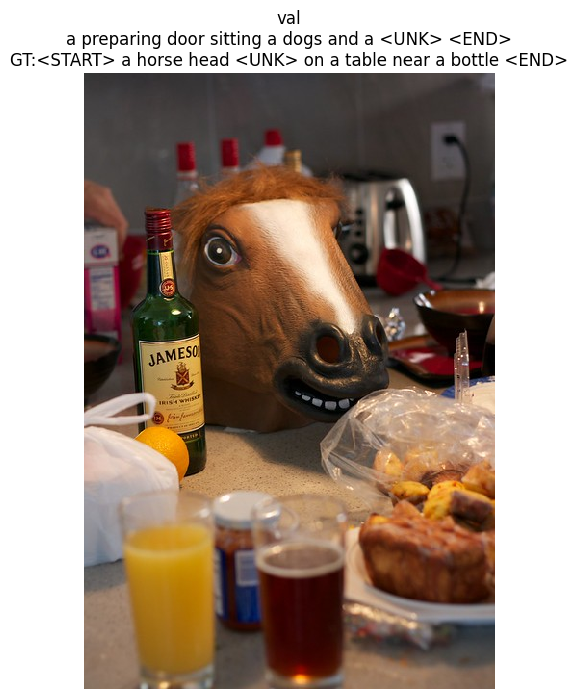

In [34]:
# If you get an error, the URL just no longer exists, so don't worry!
# You can re-sample as many times as you want.
for split in ['train', 'val']:
    minibatch = sample_coco_minibatch(small_data, split=split, batch_size=2)
    gt_captions, features, urls = minibatch
    gt_captions = decode_captions(gt_captions, data['idx_to_word'])

    sample_captions = small_rnn_model.sample(torch.from_numpy(features)).numpy()
    sample_captions = decode_captions(sample_captions, data['idx_to_word'])

    for gt_caption, sample_caption, url in zip(gt_captions, sample_captions, urls):
        img = image_from_url(url)
        # Skip missing URLs.
        if img is None: continue
        plt.imshow(img)
        plt.title('%s\n%s\nGT:%s' % (split, sample_caption, gt_caption))
        plt.axis('off')
        plt.show()

# 课内问题 1

在当前的图像描述设置中，RNN 语言模型会在每个时间步输出一个单词。不过，这个问题也可以换一种方式表述：训练网络处理_字符_（例如 'a'、'b' 等）而非单词，使其在每个时间步接收前一个字符作为输入，并尝试预测序列中的下一个字符。例如，网络可能生成如下描述：

'A', ' ', 'c', 'a', 't', ' ', 'o', 'n', ' ', 'a', ' ', 'b', 'e', 'd'

你能描述使用字符级 RNN 的图像描述模型的一项优点吗？也能描述一项缺点吗？提示：有多个正确答案，但比较单词级模型和字符级模型的参数空间可能会有所帮助。

**你的回答：**

